In [1]:
# 유방암 판정을 위한 모델을 구축

# 의학에서 최종 진단은 어디까지나 의사의 몫이지만, 이런 모델이 있으면 의사가 자신의 판단이 옳았는지 확인해 볼 수 있음
# 이렇게 인간의 판단을 보조하는 역할도 머신러닝 모델을 의미있게 활용하는 한 가지 형태


In [2]:
# 1. 데이터
# 실습에 사용할 데이터 집합은 Breat Cancer Wisconsion (Diagnostic) dataset (유방암 진단 데이터 집합)
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
# 유방암 검진에서 종양이 발견된 환자의 종양 세포를 채취하고 이를 현미경으로 분석한 결과를 수치화한 정보로 구성된 데이터
# 구체적으로 개별 세포에 대해 다음 10개의 특정값이 수치화

# a) 반지름 (세포 중심에서 주위까지의 평균 거리)
# b) 텍스쳐 (그레이스케일 값의 표준편차)
# c) 둘레 길이
# d) 면적
# e) 평활도 (반지름의 국소적인 변화 정도)
# f) 콤팩트도 (둘레^2/면적 - 1.0)
# g) 오목 면 ( 윤각선 중 오목 면의 비율)
# h) 오목 점 (윤각선에 포함된 오목 면의 수)
# i) 대칭성
# j) 프렉탈도 (해안선 근사 -1)

# 그 다음에는 각 특징값에 통계처리를 거쳐 평균, 표준편차, 최댓값의 세 가지 통계값을 계산
# 그 결과 정밀검사 대상 환자에 대해 10 * 3 = 30 이라는 수치가 계산
# 이 30개 필드(차원)의 데이터가 이 환자가 가진 종양의 악성 malignant / 양성 benign 여부와 함께 공개된 데이터 집합으로 배포
# 배포 데이터 집합에서는 악성이 0, 양성이 1로 표현

# 정밀 검사 데이터를 입력해 진단 결과를 예측하는 모델을 만드는 것이 목적
# 적용되는 업무가 의료인 만큼, 모델이 의사를 완전히 대체하기에는 현실적으로 어렵겠지만,
# 의사의 진단을 돕는 보조적인 역할은 가능

# 모델의 예측 결과는 악성 malignant / 양성 benign 두가지이고,
# 학습 데이터에는 의사가 진단한 정답 데이터가 포함되있으므로 '지도학습'

# 2. 구현하기
# 01. 공통 코드
# 공통 처리

# 불필요한 경고 메시지 무시
import warnings
warnings.filterwarnings("ignore")

# 라이브러리 임폴트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 글꼴 설정
import platform
from matplotlib import rc


if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    rc('font', family='Malgun Gothic')
else:
    rc('font', family='Malgun Gothic')

# 데이터프레임 출력용 함수
from IPython.display import Image

# 숫자 출력 조정
# 넘파이 부동소수점 출력 자리수 설정
np.set_printoptions(suppress=True, precision=4)

# 판다스 부동소수점 출력 자리수 설정
pd.options.display.float_format = '{:,.4f}'.format

# 데이터 프레임 모든 필드 출력
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 그래프 글꼴 크기 설정
plt.rcParams['font.size'] = 14

# 난수 시드
random_seed = 123

# 02. 데이터 읽어 들이기
# 사이킷런 라이브러리를 임포트
# 사이킷런은 머신러닝에서 가장 널리 사용되는 라이브러리로 여러 모델을 구현하는데 사용
# 모델 생성뿐만 아니라 데이터 전처리, 모델 평가 등 다양한 용도로 사용
# 부가 기능으로 머신러닝에서 자주 사용되는 데이터를 함수 호출만으로 받아올 수 있는 기능이 있음

# 유방암 데이터 집합
# UCI 데이터 세포 웹사이트 : https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
# 유방암 데이터 집합 읽어 들이기

# 라이브러리 임포트
from sklearn.datasets import load_breast_cancer

# 데이터 내려받기
cancer = load_breast_cancer()
print(cancer)
print(cancer.DESCR)
# 읽어 들인 데이터를 데이터프레임으로 변환하기
# 데이터프레임으로 변환하면 그 위에 해야 하는 1) 데이터 확인, 2) 데이터 전처리 과정이 간단해짐



{'data': array([[ 17.99  ,  10.38  , 122.8   , ...,   0.2654,   0.4601,   0.1189],
       [ 20.57  ,  17.77  , 132.9   , ...,   0.186 ,   0.275 ,   0.089 ],
       [ 19.69  ,  21.25  , 130.    , ...,   0.243 ,   0.3613,   0.0876],
       ...,
       [ 16.6   ,  28.08  , 108.3   , ...,   0.1418,   0.2218,   0.0782],
       [ 20.6   ,  29.33  , 140.1   , ...,   0.265 ,   0.4087,   0.124 ],
       [  7.76  ,  24.54  ,  47.92  , ...,   0.    ,   0.2871,   0.0704]],
      shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1

In [3]:
# 데이터프레임으로 변환하기

# 읽기 쉽게 한글로 칼럼이름 지정

columns = [
    '반지름_평균', '텍스처_평균', '둘레길이_평균', '면적_평균', '평활도_평균',
    '콤팩트도_평균', '오목명_평균', '오목점_평균', '대칭성_평균', '프랙탈도_평균',
    '반지름_표준편차', '텍스처_표준편차', '둘레길이_표준편차', '면적_표준편차', '평활도_표준편차',
    '콤팩트도_표준편차', '오목명_표준편차', '오목점_표준편차', '대칭성_표준편차', '프랙탈도_표준편차',
    '반지름_최대', '텍스처_최대', '둘레길이_최대', '면적_최대', '평활도_최대',
    '콤팩트도_최대', '오목명_최대', '오목점_최대', '대칭성_최대', '프랙탈도_최대'
]

# 읽어 들인 데이터를 데이터프레임으로 변환
df = pd.DataFrame(cancer.data, columns=columns)
print(df.head())

   반지름_평균  텍스처_평균  둘레길이_평균      면적_평균  평활도_평균  콤팩트도_평균  오목명_평균  오목점_평균  \
0 17.9900 10.3800 122.8000 1,001.0000  0.1184   0.2776  0.3001  0.1471   
1 20.5700 17.7700 132.9000 1,326.0000  0.0847   0.0786  0.0869  0.0702   
2 19.6900 21.2500 130.0000 1,203.0000  0.1096   0.1599  0.1974  0.1279   
3 11.4200 20.3800  77.5800   386.1000  0.1425   0.2839  0.2414  0.1052   
4 20.2900 14.3400 135.1000 1,297.0000  0.1003   0.1328  0.1980  0.1043   

   대칭성_평균  프랙탈도_평균  반지름_표준편차  텍스처_표준편차  둘레길이_표준편차  면적_표준편차  평활도_표준편차  \
0  0.2419   0.0787    1.0950    0.9053     8.5890 153.4000    0.0064   
1  0.1812   0.0567    0.5435    0.7339     3.3980  74.0800    0.0052   
2  0.2069   0.0600    0.7456    0.7869     4.5850  94.0300    0.0062   
3  0.2597   0.0974    0.4956    1.1560     3.4450  27.2300    0.0091   
4  0.1809   0.0588    0.7572    0.7813     5.4380  94.4400    0.0115   

   콤팩트도_표준편차  오목명_표준편차  오목점_표준편차  대칭성_표준편차  프랙탈도_표준편차  반지름_최대  텍스처_최대  \
0     0.0490    0.0537    0.0159    0.0300     0.

In [4]:
# 정답 데이터를 꺼냄
# cancer, target의 포맷은 넘파이이고, 값이 0인것과 1인것을 세어야 하므로 판다스의 세리스 객체로 변환
y = pd.Series(cancer.target)

# 03 데이터 확인
# 1) 입력 데이터(df)의 정답 데이터(y)의 일부를 화면에 출력

# 입력 데이터를 화면에 출력하기

# 입력 데이터의 20번째 줄부터 24번째 줄까지 화면에 출력한다
display(df[20:25])

,반지름_평균,텍스처_평균,둘레길이_평균,면적_평균,평활도_평균,콤팩트도_평균,오목명_평균,오목점_평균,대칭성_평균,프랙탈도_평균,반지름_표준편차,텍스처_표준편차,둘레길이_표준편차,면적_표준편차,평활도_표준편차,콤팩트도_표준편차,오목명_표준편차,오목점_표준편차,대칭성_표준편차,프랙탈도_표준편차,반지름_최대,텍스처_최대,둘레길이_최대,면적_최대,평활도_최대,콤팩트도_최대,오목명_최대,오목점_최대,대칭성_최대,프랙탈도_최대
20,13.0800,15.7100,85.6300,520.0000,0.1075,0.1270,0.0457,0.0311,0.1967,0.0681,0.1852,0.7477,1.3830,14.6700,0.0041,0.0190,0.0170,0.0065,0.0168,0.0024,14.5000,20.4900,96.0900,630.5000,0.1312,0.2776,0.1890,0.0728,0.3184,0.0818
21,9.5040,12.4400,60.3400,273.9000,0.1024,0.0649,0.0296,0.0208,0.1815,0.0691,0.2773,0.9768,1.9090,15.7000,0.0096,0.0143,0.0198,0.0142,0.0203,0.0030,10.2300,15.6600,65.1300,314.9000,0.1324,0.1148,0.0887,0.0623,0.2450,0.0777
22,15.3400,14.2600,102.5000,704.4000,0.1073,0.2135,0.2077,0.0976,0.2521,0.0703,0.4388,0.7096,3.3840,44.9100,0.0068,0.0533,0.0645,0.0225,0.0367,0.0044,18.0700,19.0800,125.1000,980.9000,0.1390,0.5954,0.6305,0.2393,0.4667,0.0995
23,21.1600,23.0400,137.2000,"1,404.0000",0.0943,0.1022,0.1097,0.0863,0.1769,0.0528,0.6917,1.1270,4.3030,93.9900,0.0047,0.0126,0.0171,0.0104,0.0108,0.0020,29.1700,35.5900,188.0000,"2,615.0000",0.1401,0.2600,0.3155,0.2009,0.2822,0.0753
24,16.6500,21.3800,110.0000,904.6000,0.1121,0.1457,0.1525,0.0917,0.1995,0.0633,0.8068,0.9017,5.4550,102.6000,0.0060,0.0188,0.0274,0.0113,0.0147,0.0028,26.4600,31.5600,177.0000,"2,215.0000",0.1805,0.3578,0.4695,0.2095,0.3613,0.0956


In [5]:
# 정답 데이터를 화면에 출력하기

# 정답 데이터의 20번째 줄부터 24번째 줄까지 화면에 출력한다
display(y[20:25])
print(y[20:25])

20    1
21    1
22    0
23    0
24    0
dtype: int64

20    1
21    1
22    0
23    0
24    0
dtype: int64


In [6]:
# 2) 데이터에 대한 통계 정보 확인
# 데이터프레임 df의 shape 속성값, 정답 데이터 y에 value_counts() 함수를 실행한 결과

# 데이터에 대한 통계 정보 확인하기
print(df.shape)

# 정답 데이터의 1과 0의 변수 확인
print(y.value_counts())
# 양성 1 음성 1

(569, 30)
1    357
0    212
Name: count, dtype: int64


In [7]:
# 3) 산점도 그리기
# 산점도는 2차원 데이터(x, y)를 2차원 평면 xy에 나타내는 그래프
# 아래 점의 분포를 보면 데이터의 전체적인 상황을 확인할 수 있음
# 정답 데이터의 값에 따라 색을 다르게 나타내기 위해
# 입력 데이터를 정답 데이터 값이 0인 그룹 (df0)과 1인 그룹(df1)으로 나눔

# 산포도를 그리기 위한 준비

# 입력 데이터를 대응하는 정답 데이터의 값에 따라 분할한다

# 정답 데이터 = 0 (악성)인 데이터 골라내기
df0 = df[y == 0]

# 정답 데이터 = 1 (양성)인 데이터 골라내기
df1 = df[y == 1]

display(df0.head())


,반지름_평균,텍스처_평균,둘레길이_평균,면적_평균,평활도_평균,콤팩트도_평균,오목명_평균,오목점_평균,대칭성_평균,프랙탈도_평균,반지름_표준편차,텍스처_표준편차,둘레길이_표준편차,면적_표준편차,평활도_표준편차,콤팩트도_표준편차,오목명_표준편차,오목점_표준편차,대칭성_표준편차,프랙탈도_표준편차,반지름_최대,텍스처_최대,둘레길이_최대,면적_최대,평활도_최대,콤팩트도_최대,오목명_최대,오목점_최대,대칭성_최대,프랙탈도_최대
0,17.9900,10.3800,122.8000,"1,001.0000",0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,"2,019.0000",0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.5700,17.7700,132.9000,"1,326.0000",0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,"1,956.0000",0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,19.6900,21.2500,130.0000,"1,203.0000",0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,"1,709.0000",0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,20.2900,14.3400,135.1000,"1,297.0000",0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,"1,575.0000",0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


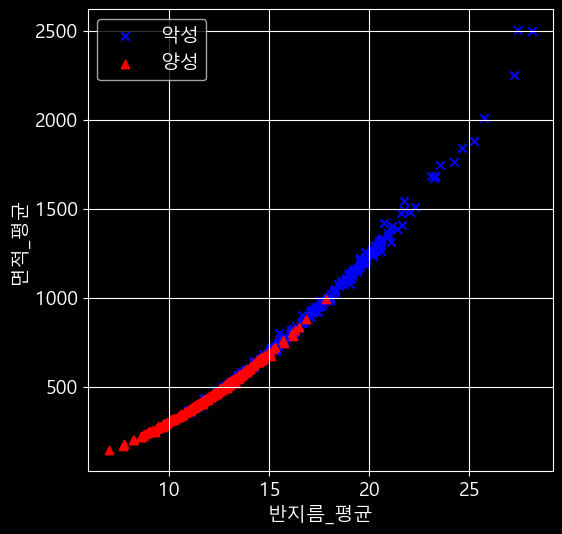

In [8]:
# 출력값을 보면 '반지름 평균' 필드의 값이 df0(정답 데이터 값이 0인 그룹)에서 더 큰 경향이 있다'는 걸 알 수 있음
# 산점도 그리기

# 그래프의 크기를 설정
plt.figure(figsize = (6,6))

# 목적변수 값이 1인 데이터의 산포도 그리기
plt.scatter(df0['반지름_평균'], df0['면적_평균'], marker='x', c='b', label='악성')
# 목적변수 값이 1인 데이터의 산포도 그리기
plt.scatter(df1['반지름_평균'], df1['면적_평균'], marker='^', c='red', label='양성')

# 그리드 표시
plt.grid()
# 레이블 표시
plt.xlabel('반지름_평균')
plt.ylabel('면적_평균')
# 범례 그리기
plt.legend()
# 화면에 전체 그래프를 출력
plt.show()

In [9]:
# 출력된 산점도를 보면 예상한 내용 (반지름 평균의 값이 df0(악성 그룹)에서 더 큰 경향이 있다.)이 맞았음을 알 수 있음

# 04. 데이터 전처리

# 입력 데이터를 두 개의 필드로 줄이기
# 실제 데이터를 대상으로 모델을 만들 때 이 단계에서 큰 수고가 들지만
# 모델을 만들기 쉬운 데이터를 골랐기 때문에 입력 데이터를 두 가지로 줄이는 작업만 함

input_columns = ['반지름_평균', '면적_평균']
x = df[input_columns]
display(x.head())

,반지름_평균,면적_평균
0,17.9900,"1,001.0000"
1,20.5700,"1,326.0000"
2,19.6900,"1,203.0000"
3,11.4200,386.1000
4,20.2900,"1,297.0000"


In [10]:
# 05. 데이터 분류
# 데이터 분할에는
# 1) 목적변수(정답 데이터)와 입력변수(입력 데이터)를 분할 하는 것(좌우 분할)과
# 2) 학습 데이터와 검증 데이터를 분할 하는 것 (상하 분할) 두 가지가 있음
# 지금 데이터 집합은 데이터를 읽어 들었을 때 이미 목적 변수와 입력 변수가 나뉘어 있었으므로
# 좌우 분할은 생략하고 상하 분할만 구현

# 학습 데이터와 검증 데이터 분할하기
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = (train_test_split(x,y,test_size=0.3,train_size=0.7,random_state=random_seed))
# train 이 학습, test가 검증

# train_test_split()
# 원래 데이터의 x와 y를 각각 학습 데이터(train)와 검증 데이터(test)로 분할
# 분할된 데이터는 x_train, x_test, y_train, y_test 변수에 각각 대입
# 분할 비율은 train_size와 test_size 두 개의 인자에 지정할 수 있음
# 여기서 7:3으로 분할하기 위해 0.7과 0.3으로 두 인자의 값을 지정
# 데이터를 분할하기 전 원래 데이터를 무작위로 섞기 위해 난수를 사용
# 무작위 섞기에 사용된 난수 시드의 값을 입력받는 파라미터가 random_state
# random_state값을 지정하면 항상 같은 결과가 나옴

# 분할된 데이터를 확인하기(요소 수)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(398, 2)
(398,)
(171, 2)
(171,)


In [11]:
# 데이터 확인
display(x_train.head())
display(y_train.head())
display(x_test.head())
display(y_test.head())

,반지름_평균,면적_평균
559,11.5100,403.5000
295,13.7700,582.7000
264,17.1900,928.3000
125,13.8500,588.7000
280,19.1600,"1,138.0000"


559    1
295    1
264    0
125    1
280    0
dtype: int64

,반지름_평균,면적_평균
333,11.2500,390.0000
273,9.7420,289.9000
201,17.5400,951.6000
178,13.0100,526.4000
85,18.4600,"1,075.0000"


333    1
273    1
201    0
178    1
85     0
dtype: int64

In [13]:
# 실험 결과를 보면 왼쪽 끝의 인덱스가 분할하기 전에 무작위 섞었음을 알 수 있음

# 이진분류: logistic

# 06. 알고리즘 선택하기
# LogisticRegression 로시스틱 회귀 (분류 알고리즘)을 사용

# 알고리즘 선택
from sklearn.linear_model import LogisticRegression

algorithm = LogisticRegression(random_state=random_seed) # 알고리즘 초기화
print(algorithm)

# 07. 학습
# 학습을 진행할 때는 만든 모델의 fit() 함수를 실행
algorithm.fit(x_train, y_train) # 첫 번째 인자는 표 형식으로 구성되니 입력 데이터
# 두 번째 인자는 입력 데이터와 대응하는 응답 데이터
print(algorithm)


LogisticRegression(random_state=123)
LogisticRegression(random_state=123)


In [15]:
print(algorithm.get_params())
# 생성된 모델(algorithm)의 파라미터 값들을 출력
# random_state 외의 인자는 지정하지 않았기 때문에 그 외의 여러 가지 인자가 기본값으로 설정

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 100, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 123, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [17]:
# 08. 예측
# 예측을 구현할때는 예측 대상 입력 데이터가 표 형식으로 들어 있는 변수를 인자로 predict() 함수로 호출

# predict 함수를 호출한다
y_pred = algorithm.predict(x_test)

# 예측 결과를 확인
print(y_pred)

[1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1
 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1
 0 1 1 0 0 0 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 1 1 0 0 0 1 0 1 0 1 1 0
 1 0 1 1 1 1 1 1 0 0 0 1 1 1 1 0 1 1 1 0 0 0 1]


In [18]:
# 09. 평가
# 검증 데이터를 대상으로 정답 데이터와 예측 결과가 얼마나 일치하는지 비교
# 정답 데이터와 예측 결과 비교하기

# 정답 데이터를 앞에서부터 10건 추려냄
# y_test는 데이터프레임으로 value 속성에 담긴 넘파이 배열로 변환한다

In [19]:
y_test10 = y_test[:10].values
print(y_test10)

[1 1 0 1 0 1 1 0 1 1]


In [20]:
# 예측 결과를 앞에서 부터 10건 추려냄
y_pred10 = y_pred[:10]
print(y_pred10)

[1 1 0 1 0 1 1 1 0 1]


In [23]:
# 정답을 맞춘 건수 세기

# 정답 데이터 == 예측 결과
w1 = (y_test10 == y_pred10)
print(w1)

[ True  True  True  True  True  True  True False False  True]


In [24]:
# 정답을 맞힌 건수
w2 = w1.sum()
print(w2)

8


In [27]:
# 전체 데이터에 같은 방법을 적용
# 정확도 계산하기

# 정답을 맞힌 건수를 계산
w = (y_test.values == y_pred)
correct = w.sum()

# 검증 데이터 전체 건 수
N = len(w)
print(N)

171


In [28]:
# 정확도 = (정답 수)/ (검증 데이터 전체 건수)
score = correct / N
# 정확도 출력
print(f'정확도:{score: .04f}')

정확도: 0.8713


In [29]:
# 더 간단히 정확도를 측정하는 방법으로는 score() 함수 사용
score = algorithm.score(x_test, y_test)
print(f'정확도:{score: .04f}')

정확도: 0.8713


In [30]:
# 10. 튜닝
# 두 개의 필드만 사용했는데 30개의 필드를 모두 사용한다면 힌트가 늘어날 것이므로 정확도가 향상
# 모델의 정확도 개선하기

# 원래 있던 30개 필드를 모두 포함해 학습 데이터와 검증 데이터를 다시 만든다.

x2_train, x2_test, y_train, y_test = (train_test_split(df,y,test_size=0.3,train_size=0.7,random_state=random_seed))
# y는 이진으로 되어있기 때문에 그대로 쓰면 됨

# 로지스틱 회귀도 예측 모델 다시 만들기
algorithm2 = LogisticRegression(random_state=random_seed)

# 새로 만든 학습 데이터로 학습을 진행
algorithm2.fit(x2_train, y_train)

# 검증 데이터로 정확도를 높이기
score2 = algorithm2.score(x2_test, y_test)
print(f'score2:{score2:.04f}')

score2:0.9649
